Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            1.0000    100.0%      1.0%    0.0792
  2            1.0000    100.0%      0.2%    0.1279
  3            1.0000    100.0%      0.1%    0.0340
  4            1.0000    100.0%      0.2%    0.0038
  5            0.9999    100.8%      1.5%    0.0030
  6            0.8804     51.7%     64.7%    0.0016
Global FF coverage: 100.0%   FB correction: 0.3%
Global correlation FF↔tot: 1.0000


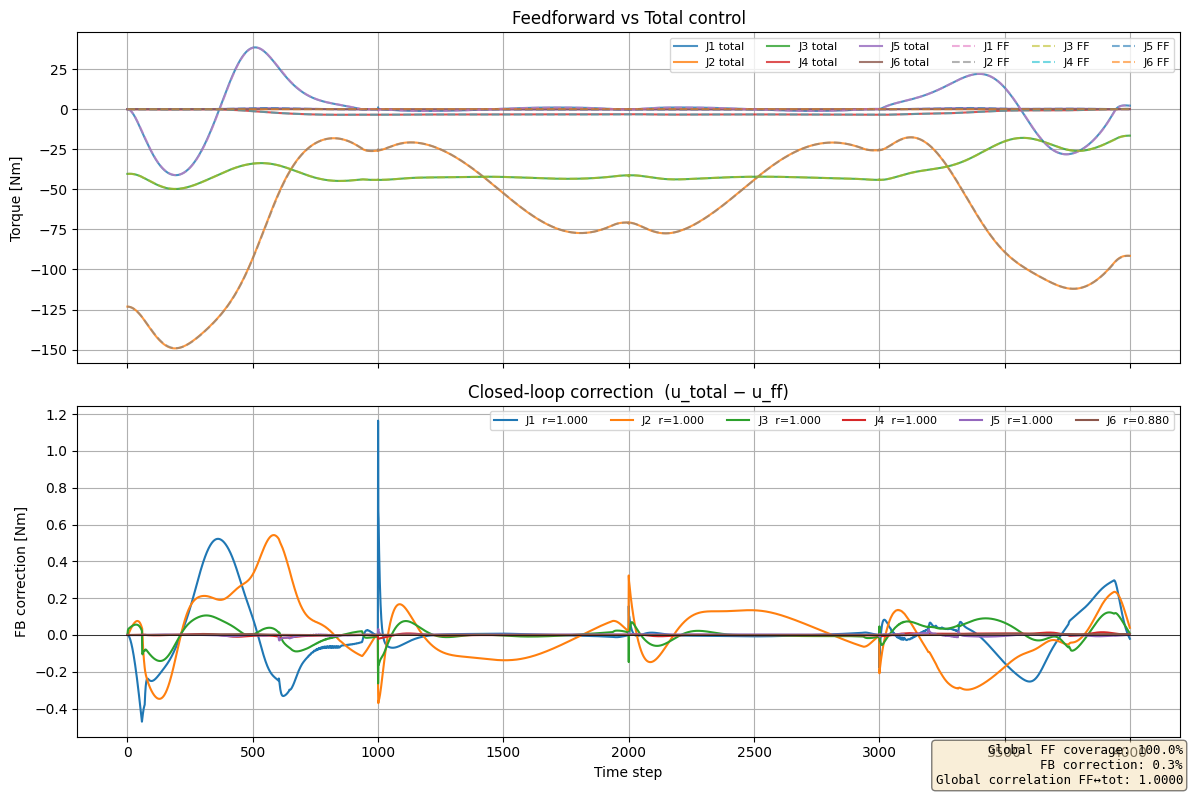

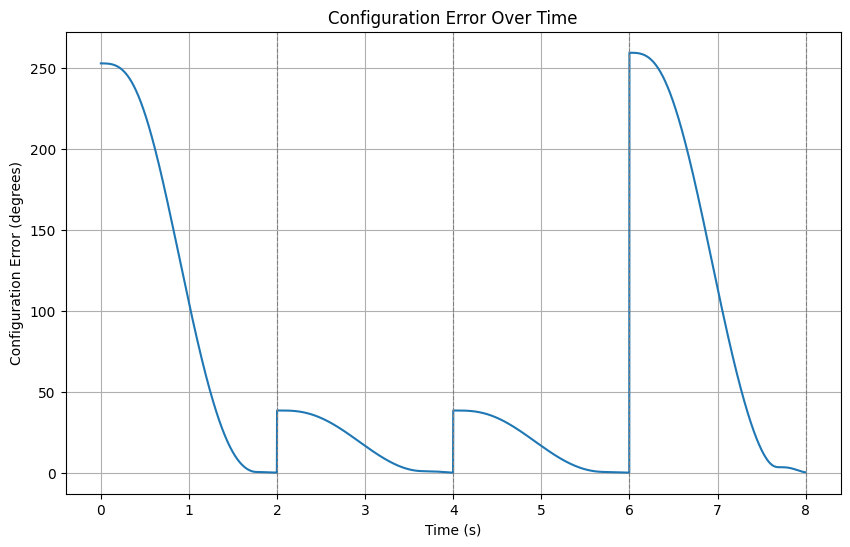

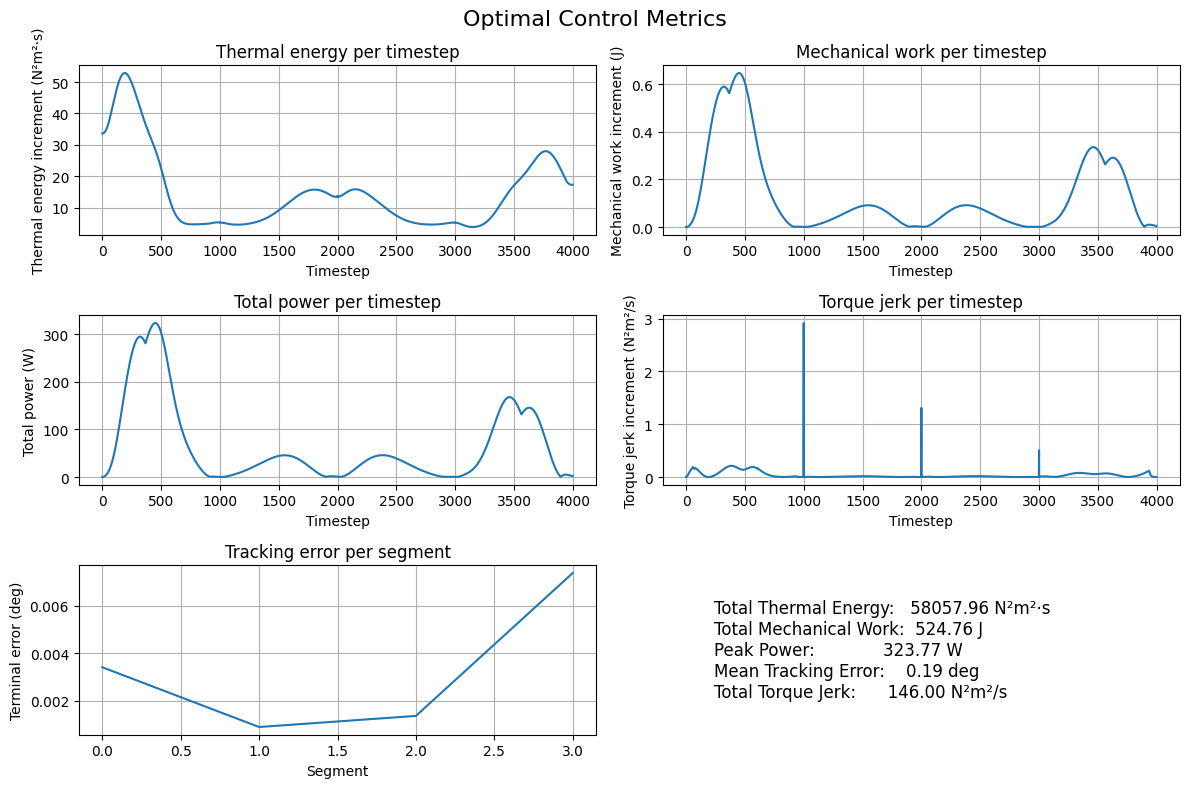

Cost: 23725.705237322145, Controller time: 0.10923457145690918


In [10]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox, Trajectories, Test1
import optimal.metrics as metrics
import numpy as np
import time

type = UR10_sandbox
pd = Test1.PDValues.BayesianOptimization.TPE.Global
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof

controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start_time = time.time()
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                            x_goal=target, 
                                            T=1000, DT=DT, kp=pd.kp, kd=pd.kd,
                                            alpha=pd.alpha,
                                            interpolation=pd.interpolation, # linear, trapezoidal, cubic, quintic
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]
end_time = time.time()
controller_time = end_time - start_time
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=pd.kp, kd=pd.kd)
robot_mj_model.plot_feedback_part(us_real, us)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
metrics.plot_metrics(us_real, xs_real, DT, path[1:], segment_lengths=[1000]*len(path))
cost = metrics.unified_cost(us_real, xs_real, DT, path[1:], segment_lengths=[1000]*len(path))
print(f"Cost: {cost}, Controller time: {controller_time}")
robot_mj_model.reset()

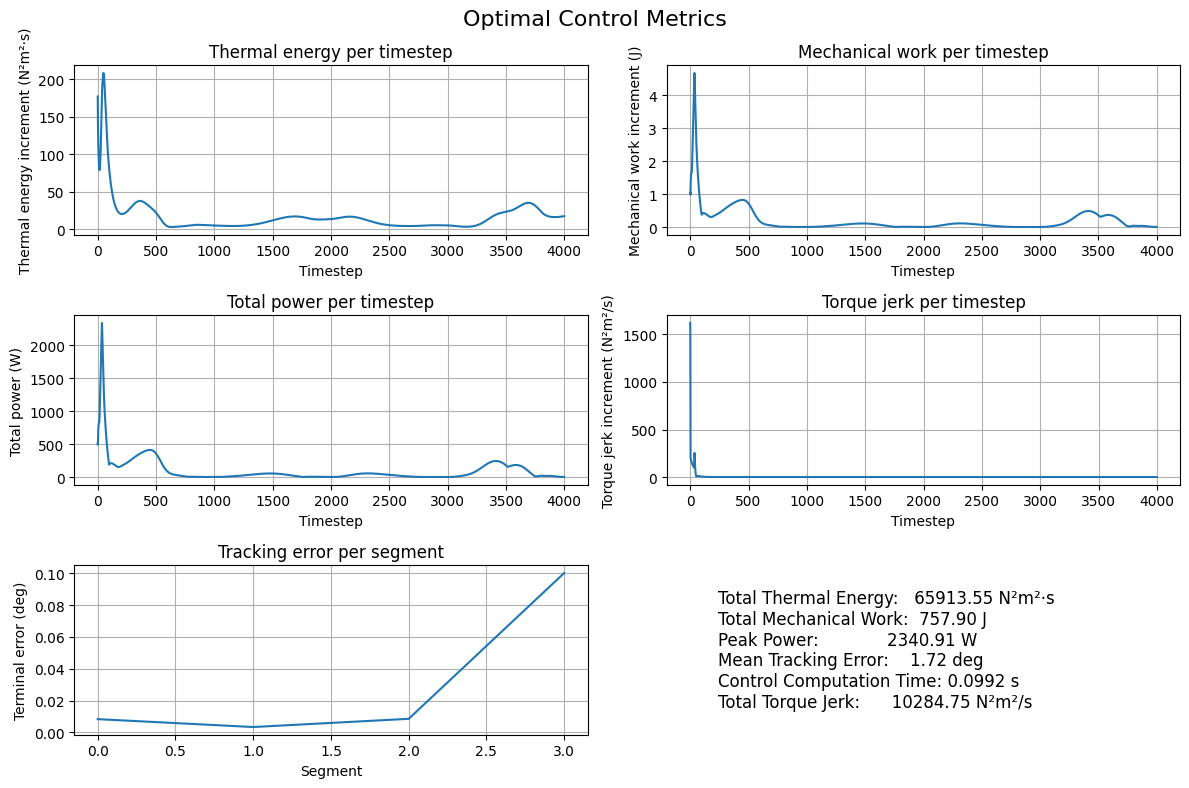

In [8]:
from optimal.metrics import plot_metrics

plot_metrics(us_real, xs_real, DT, path[1:], [1000]*(len(path)-1), controller_time)

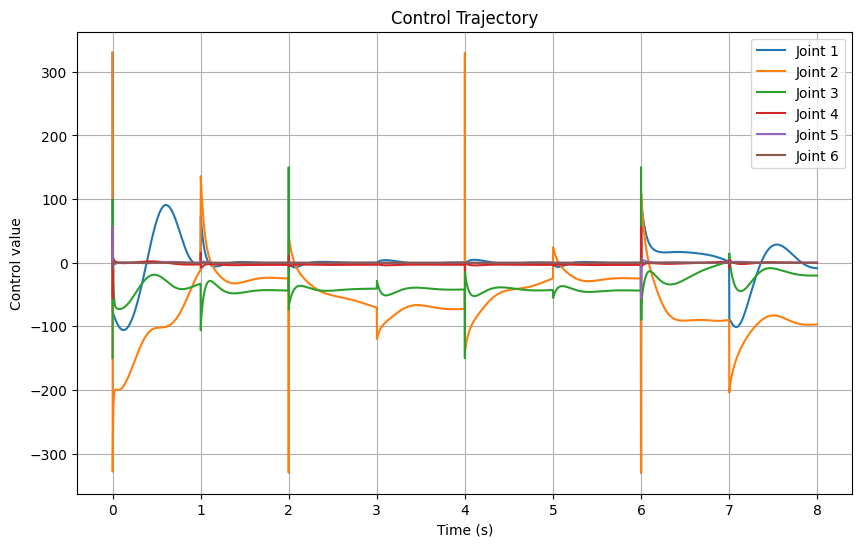

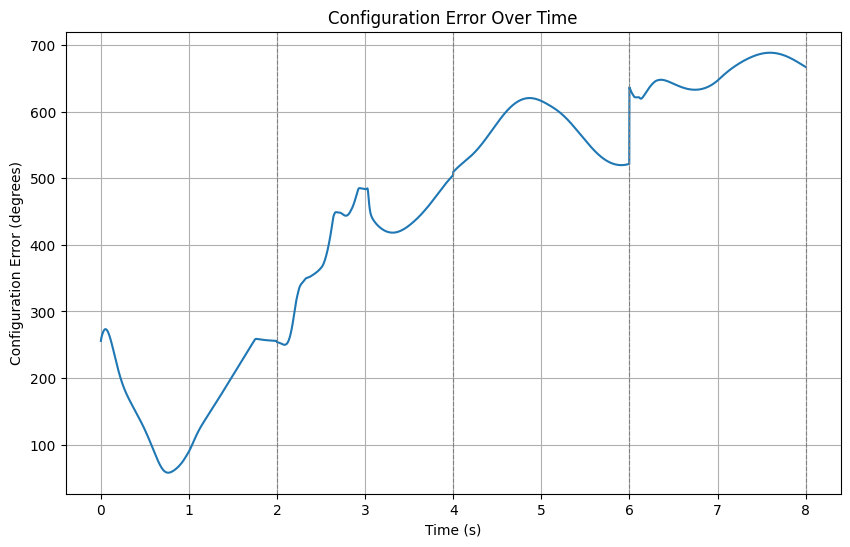

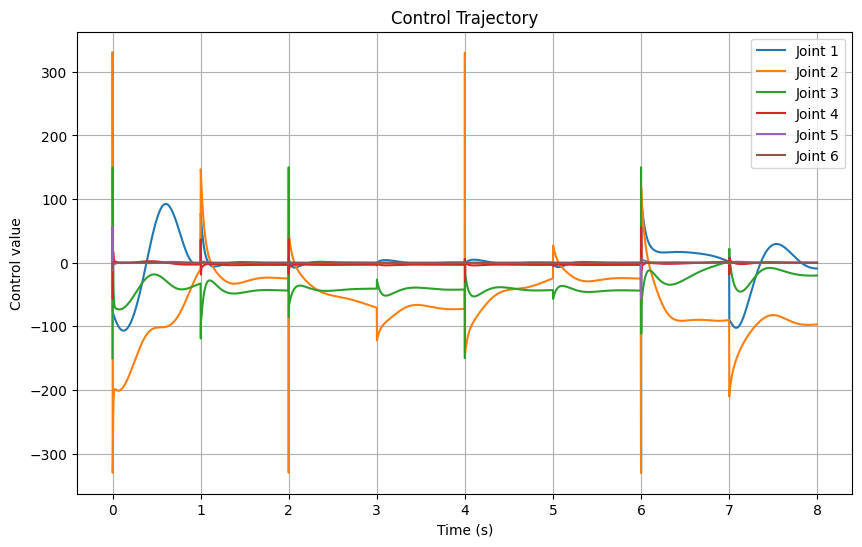

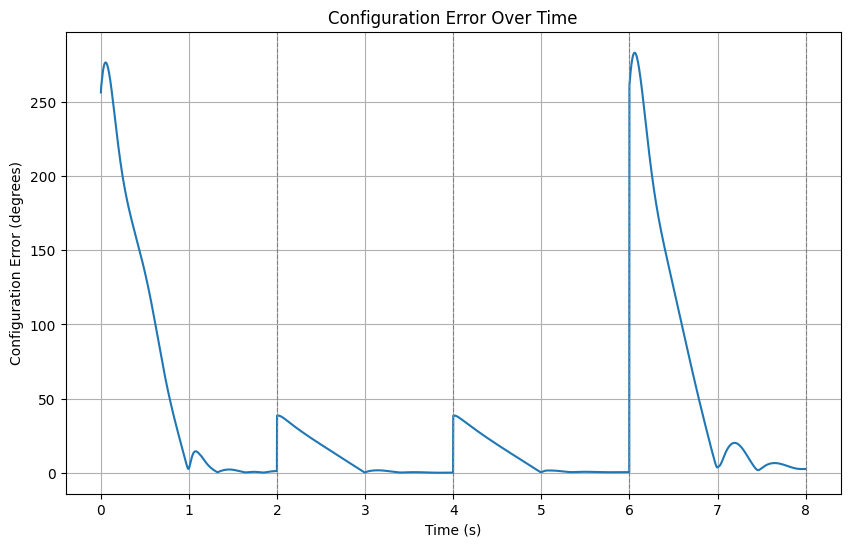

In [6]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

